# Illusion or Algorithm?
Investigating Memorization, Emergence, and Symbolic Processing in In-Context Learning.

This notebook demonstrates the basic functionalities.

In [27]:
from types import SimpleNamespace as Namespace

import nltk
import torch
torch.set_grad_enabled(False)
from transformer_lens import HookedTransformer

import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from scipy.stats import pearsonr

from icl_analysis.generate_data import InductionDataset

In [2]:
inference_dtype = torch.bfloat16
model = HookedTransformer.from_pretrained_no_processing("EleutherAI/pythia-12b", torch_dtype=inference_dtype)

Loading checkpoint shards: 100%|██████████| 3/3 [00:14<00:00,  4.98s/it]


Loaded pretrained model EleutherAI/pythia-12b into HookedTransformer


In [3]:
nltk.data.path.append('/mnt/beegfs/work/niu/codes/icl_emergence/data')

## Data Generation
This section generates synthetic tasks for in-context learning experiments.  
It uses the `InductionDataset` instance `ds` to create a set of prompts and their corresponding targets.

The function `ds.generate_lsc(10)` returns two lists:  
- `prompts`: input sequences for the model  
- `targets`: expected outputs for each prompt

The other ICL tasks: `generate_lscg`, `generate_wc`, `generate_wi`, `generate_translate` and `generate_cf` all follow the same template.

In [4]:
config = Namespace(seed=0)
ds = InductionDataset(config, model.tokenizer)
ds.parse_brown()

In [5]:
ds.generate_lsc(10)

([' di 343 negotiate fetch castle unreal dies permitting cynical Sacramento Grove bounding Los communicated seventh pumping di 343 negotiate fetch castle',
  ' realized textures away Lands helium handled Reply organizational spring whirl suggestive permanent inevitably fascinating accomplishment antibodies realized textures away Lands helium',
  ' watches Radio ideal inaccurate Amendment Birmingham Without Eye 1955 Winnipeg collector routed inaccessible prototype jersey fracture watches Radio ideal inaccurate Amendment',
  ' disordered disorders Athens introducing cables Let thriving publicly investment accompanied handled Shah listening 395 Kenneth bones disordered disorders Athens introducing cables',
  ' bounding defensive conductor Brotherhood Record images lamb cancelled mount Shall negligent 1885 recreational spaced ionic 101 bounding defensive conductor Brotherhood Record',
  ' Preston Ring Tales Jennifer 1955 Top compounds retain runner Exposure bushes history association appea

## Reproducing Results: Token Frequency and ICL Performance

This section serves two main purposes:

1. **Experiment Instructions:**  
    We demonstrate how to use the generated synthetic in-context learning (ICL) data. The previous cells show how to generate and access example prompts and targets using the `InductionDataset` instance `ds`.

2. **Tokenizer Reproduction:**  
    To reproduce our exerpiments in Section 4.2 on the paper.


In [6]:
def run_acc(result_prompts, result_labels, model):

    labels = torch.tensor(result_labels)
    preds = model(torch.tensor(result_prompts))[:, -1]
    top_preds = preds.argmax(-1)

    return (labels == top_preds.cpu()).sum().item()

In [43]:
index_ranges, acc_scores = [], []
for tokenizer_index in tqdm(range(0, 50000, 1000)):
    result_prompts, result_labels = ds.generate_lsc_token((tokenizer_index, tokenizer_index + 1000))
    acc = run_acc(result_prompts, result_labels, model)
    index_ranges.append(tokenizer_index)
    acc_scores.append(acc)

100%|██████████| 50/50 [02:54<00:00,  3.49s/it]


/scratch/248974/ipykernel_1060997/2746814071.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0%}'.format(x) for x in vals])


Text(0.5, 1.0, 'LSC Task Performance Across Token Sample Ranges')

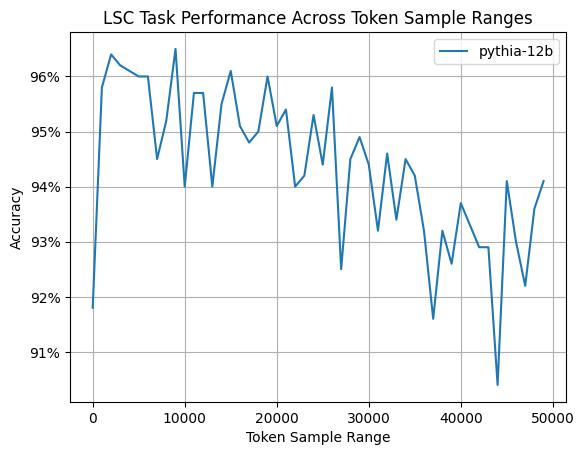

In [44]:
fig, ax = plt.subplots()

sns.lineplot(x=index_ranges, y=[x/1000 for x in acc_scores], label=f'pythia-12b', ax=ax)

vals = ax.get_yticks()
ax.set_yticklabels(['{:.0%}'.format(x) for x in vals])
ax.grid()

# Label the axes and give a title
plt.xlabel('Token Sample Range')
plt.ylabel('Accuracy')
plt.title('LSC Task Performance Across Token Sample Ranges')

### Calculate the Pearson correlation coefficient between token sample range and accuracy scores.

In [ ]:
# 1. Using all index ranges (including 0-1000)
corr_full, pval_full = pearsonr(index_ranges, acc_scores)
print(f"Pearson correlation (all ranges): {corr_full:.4f}, p-value: {pval_full:.4g}")

# 2. Excluding the first index range (0-1000), which contains many unusual tokens
corr_excl_first, pval_excl_first = pearsonr(index_ranges[1:], acc_scores[1:])
print(f"Pearson correlation (excluding first range): {corr_excl_first:.4f}, p-value: {pval_excl_first:.4g}")

Pearson correlation (all ranges): -0.6584, p-value: 2.024e-07
Pearson correlation (excluding first range): -0.7724, p-value: 8.053e-11


### Working with LLaMA models

In [38]:
inference_dtype = torch.bfloat16
llama_model = HookedTransformer.from_pretrained_no_processing("meta-llama/Llama-3.1-8B", torch_dtype=inference_dtype)

llama_ds = InductionDataset(config, model.tokenizer)
llama_ds.parse_brown()

index_ranges, acc_scores = [], []
for tokenizer_index in tqdm(range(0, 128000, 1000)):
    result_prompts, result_labels = llama_ds.generate_lsc_token((tokenizer_index, tokenizer_index + 1000))
    acc = run_acc(result_prompts, result_labels, llama_model)
    index_ranges.append(tokenizer_index)
    acc_scores.append(acc)

Loading checkpoint shards: 100%|██████████| 4/4 [00:06<00:00,  1.72s/it]


Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer


100%|██████████| 128/128 [04:53<00:00,  2.29s/it]


/scratch/248974/ipykernel_1060997/3231714789.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0%}'.format(x) for x in vals])


Text(0.5, 1.0, 'LSC Task Performance Across Token Sample Ranges')

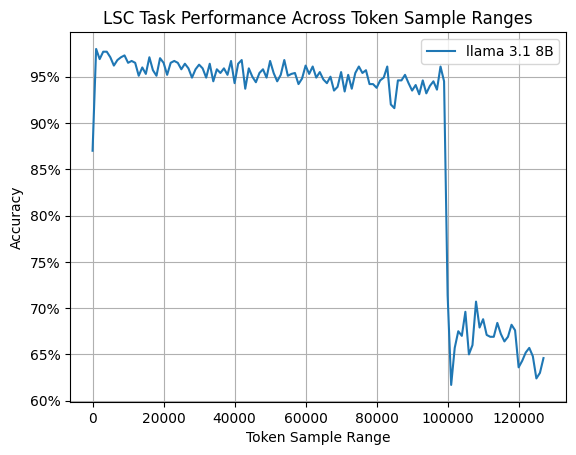

In [40]:
fig, ax = plt.subplots()

sns.lineplot(x=index_ranges, y=[x/1000 for x in acc_scores], label=f'llama 3.1 8B', ax=ax)

vals = ax.get_yticks()
ax.set_yticklabels(['{:.0%}'.format(x) for x in vals])
ax.grid()

# Label the axes and give a title
plt.xlabel('Token Sample Range')
plt.ylabel('Accuracy')
plt.title('LSC Task Performance Across Token Sample Ranges')

The LLaMA tokenizer uses a 128K token vocabulary, composed of 100K tokens from the tiktoken tokenizer, plus 28K additional tokens aimed at improving support for non-English languages. While the first 10K tokens mostly capture frequent and semantically meaningful substrings in English (e.g., common words, prefixes, suffixes), the additional 28K tokens are much more heterogeneous and sparsely distributed across the training corpus. This tokenizer setup explains the big dip in performance we observe in the figure above.

In [42]:
# 1. Using all index ranges (including 0-1000)
corr_full, pval_full = pearsonr(index_ranges, acc_scores)
print(f"Pearson correlation (all ranges): {corr_full:.4f}, p-value: {pval_full:.4g}")

# 2. Pearson correlation on the tiktoken (regular tokenizer) tokens
corr_tiktoken, pval_tiktoken = pearsonr(index_ranges[:100], acc_scores[:100])
print(f"Pearson correlation (tiktoken (first 100K) excluding first range): {corr_tiktoken:.4f}, p-value: {pval_tiktoken:.4g}")

# 3. Tiktoken (regular tokenizer) tokens excluding the first index range (0-1000), which contains many unusual tokens
corr_excl_first, pval_excl_first = pearsonr(index_ranges[1:100], acc_scores[1:100])
print(f"Pearson correlation (tiktoken (first 100K) excluding first range): {corr_excl_first:.4f}, p-value: {pval_excl_first:.4g}")

Pearson correlation (all ranges): -0.7481, p-value: 3.44e-24
Pearson correlation (tiktoken (first 100K) excluding first range): -0.4702, p-value: 7.997e-07
Pearson correlation (tiktoken (first 100K) excluding first range): -0.7011, p-value: 6.451e-16
